In [1]:
# IMPORTS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind, chi2_contingency, mannwhitneyu, f_oneway
from statsmodels.stats.proportion import proportions_ztest
import warnings

warnings.filterwarnings('ignore')

# --- Display Settings ---
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)

In [2]:
# LOAD DATA

# --- AB Groups (SQL prepared summary table) ---
ab_groups = pd.read_csv("simulated_ab_groups.csv")

# --- Individual AB Test Tables ---
ab_test_1 = pd.read_csv("ab_test_1.csv")
ab_test_2 = pd.read_csv("ab_test_2.csv")
ab_test_3 = pd.read_csv("ab_test_3.csv")
ab_test_4 = pd.read_csv("ab_test_4.csv")
ab_test_5 = pd.read_csv("ab_test_5.csv")

# --- Quick Shape Check ---
print("AB Groups shape :", ab_groups.shape)
print("AB Test 1 shape :", ab_test_1.shape)
print("AB Test 2 shape :", ab_test_2.shape)
print("AB Test 3 shape :", ab_test_3.shape)
print("AB Test 4 shape :", ab_test_4.shape)
print("AB Test 5 shape :", ab_test_5.shape)

# --- Preview ---
print("\nAB Groups Summary:")
display(ab_groups)

AB Groups shape : (10, 5)
AB Test 1 shape : (746290, 6)
AB Test 2 shape : (1407580, 6)
AB Test 3 shape : (1407580, 6)
AB Test 4 shape : (1407580, 7)
AB Test 5 shape : (27146, 7)

AB Groups Summary:


,test_name,group_label,total_users,total_conversions,conversion_rate
0,Test1_Morning_vs_Evening,Control_Morning,439169,3335,0.7594
1,Test1_Morning_vs_Evening,Treatment_Evening,307121,2671,0.8697
2,Test2_Single_vs_MultiSession,Control_Single,1225947,5319,0.4339
3,Test2_Single_vs_MultiSession,Treatment_Multi,181633,6400,3.5236
4,Test3_Weekday_vs_Weekend,Control_Weekday,1059028,9574,0.9040
5,Test3_Weekday_vs_Weekend,Treatment_Weekend,348552,2145,0.6154
6,Test4_Light_vs_HeavyViewer,Control_Light,1294129,5604,0.4330
7,Test4_Light_vs_HeavyViewer,Treatment_Heavy,113451,6115,5.3900
8,Test5_Abandoner_Return_Pattern,Control_Abandoned_NoReturn,17596,0,0.0000
9,Test5_Abandoner_Return_Pattern,Treatment_Abandoned_Returned,9550,0,0.0000


In [3]:
# IMPORTANT DISCLAIMER

print("=" * 60)
print("IMPORTANT DISCLAIMER")
print("=" * 60)

print("""
This dataset does NOT contain real controlled experiments.

No users were randomly assigned to treatment/control
groups during original data collection.

What we demonstrate here:
→ Behavioral and time-based user splits
→ Full statistical testing framework
→ Sample size planning methodology

This is a retrospective simulation approach commonly
used in e-commerce analytics when A/B testing is not available.

SQL 10 prepared data is used here.
""")

print("=" * 60)

IMPORTANT DISCLAIMER

This dataset does NOT contain real controlled experiments.

No users were randomly assigned to treatment/control
groups during original data collection.

What we demonstrate here:
→ Behavioral and time-based user splits
→ Full statistical testing framework
→ Sample size planning methodology

This is a retrospective simulation approach commonly
used in e-commerce analytics when A/B testing is not available.

SQL 10 prepared data is used here.



In [4]:
# ============================================================
# SECTION 1: PRE-TEST PLANNING
# Sample size calculation before running tests
# ============================================================

from statsmodels.stats.power import NormalIndPower
# --- Baseline CVR ---
baseline_cvr = ab_groups['conversion_rate'].mean() / 100
# --- Test Parameters ---
alpha = 0.05      # significance level
power = 0.80      # statistical power
mde   = 0.10      # minimum detectable effect (10%)
# --- Expected Lift ---
improved_cvr = baseline_cvr * (1 + mde)
# --- Effect Size (Cohen's h for proportions) ---
effect_size = (2 * np.arcsin(np.sqrt(improved_cvr)) - 2 * np.arcsin(np.sqrt(baseline_cvr)))
# --- Sample Size Calculation ---
analysis = NormalIndPower()

sample_size = analysis.solve_power(effect_size=effect_size, alpha=alpha, power=power, ratio=1.0)

# --- Total Available Users ---
total_users = (ab_test_1['visitorid'].nunique() + ab_test_2['visitorid'].nunique())

# --- Output ---
print("=" * 50)
print("PRE-TEST PLANNING")
print("=" * 50)

print(f"Baseline CVR              : {baseline_cvr*100:.4f}%")
print(f"MDE (relative)            : {mde*100:.0f}%")
print(f"Expected improved CVR     : {improved_cvr*100:.4f}%")
print(f"Alpha                     : {alpha}")
print(f"Power                     : {power}")
print(f"Effect size (Cohen's h)   : {effect_size:.4f}")
print(f"Required sample per group : {int(sample_size):,}")
print(f"Required total sample     : {int(sample_size*2):,}")
print(f"Available users           : {total_users:,}")

print("\nFeasibility check:")
if total_users >= sample_size * 2:
    print("Enough users for statistical testing")
else:
    print("Limited users — interpret results carefully")

PRE-TEST PLANNING
Baseline CVR              : 1.2929%
MDE (relative)            : 10%
Expected improved CVR     : 1.4222%
Alpha                     : 0.05
Power                     : 0.8
Effect size (Cohen's h)   : 0.0112
Required sample per group : 125,684
Required total sample     : 251,368
Available users           : 2,153,870

Feasibility check:
Enough users for statistical testing


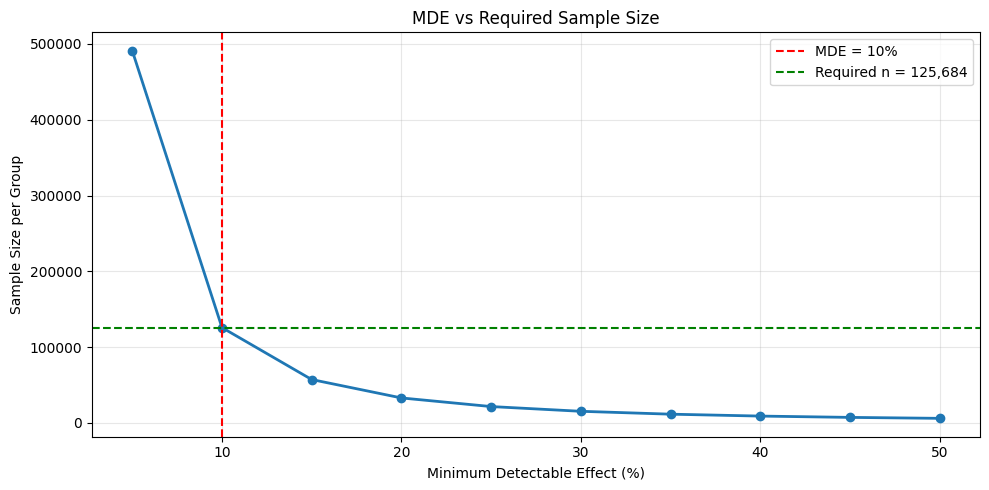

In [9]:
# ============================================================
# SECTION 1 CONTINUED: SAMPLE SIZE PLANNING CURVE
# ============================================================

# --- MDE range ---
mde_range = np.arange(0.05, 0.51, 0.05)
sample_sizes = []

# --- Compute sample sizes for each MDE ---
for mde_val in mde_range:

    improved = baseline_cvr * (1 + mde_val)

    eff_size = (
        2 * np.arcsin(np.sqrt(improved))
        - 2 * np.arcsin(np.sqrt(baseline_cvr))
    )

    n = analysis.solve_power(
        effect_size=eff_size,
        alpha=alpha,
        power=power,
        ratio=1.0
    )

    sample_sizes.append(int(n))

# --- Plot ---
plt.figure(figsize=(10, 5))

plt.plot(
    mde_range * 100,
    sample_sizes,
    'o-',
    linewidth=2)

plt.axvline(
    x=mde * 100,
    linestyle='--',
    color='red',
    label=f'MDE = {mde*100:.0f}%')

plt.axhline(
    y=int(sample_size),
    linestyle='--',
    color='green',
    label=f'Required n = {int(sample_size):,}')

plt.title('MDE vs Required Sample Size')
plt.xlabel('Minimum Detectable Effect (%)')
plt.ylabel('Sample Size per Group')

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig('sample_size_curve.png', dpi=150)
plt.show()

In [16]:
# ============================================================
# HELPER FUNCTION
# Run two proportion z-test for each AB test

# ============================================================

def run_ab_test(test_name, control_df, treatment_df,
                control_label, treatment_label):

    # --- Basic Metrics ---
    control_n    = len(control_df)
    treatment_n  = len(treatment_df)

    control_conv = control_df['converted'].sum()
    treatment_conv = treatment_df['converted'].sum()

    control_cvr  = control_conv / control_n
    treatment_cvr = treatment_conv / treatment_n

    # --- Two-Proportion Z-Test ---
    count = np.array([control_conv, treatment_conv])
    nobs  = np.array([control_n, treatment_n])

    z_stat, p_val = proportions_ztest(count, nobs)

    # --- Lift ---
    abs_lift = treatment_cvr - control_cvr
    rel_lift = (abs_lift / control_cvr) * 100 if control_cvr > 0 else 0

    # --- Confidence Interval ---
    se = np.sqrt(
        control_cvr * (1 - control_cvr) / control_n +
        treatment_cvr * (1 - treatment_cvr) / treatment_n
    )

    ci_lower = abs_lift - 1.96 * se
    ci_upper = abs_lift + 1.96 * se

    # --- Print Results ---
    print("=" * 55)
    print(f"TEST: {test_name}")
    print("=" * 55)

    print(f"Control ({control_label})")
    print(f"  Users       : {control_n:,}")
    print(f"  Conversions : {control_conv:,}")
    print(f"  CVR         : {control_cvr*100:.4f}%")

    print(f"\nTreatment ({treatment_label})")
    print(f"  Users       : {treatment_n:,}")
    print(f"  Conversions : {treatment_conv:,}")
    print(f"  CVR         : {treatment_cvr*100:.4f}%")

    print("\nResults:")
    print(f"  Absolute Lift : {abs_lift*100:.4f}%")
    print(f"  Relative Lift : {rel_lift:.2f}%")
    print(f"  95% CI        : [{ci_lower*100:.4f}%, {ci_upper*100:.4f}%]")
    print(f"  Z-Statistic   : {z_stat:.4f}")
    print(f"  P-Value       : {p_val:.6f}")

    # --- Decision ---
    print("\nDecision:")
    if p_val < 0.05:
        winner = treatment_label if treatment_cvr > control_cvr else control_label
        print(f"Significant result. Winner: {winner}")
    else:
        print("Not significant. No clear winner")

    # --- Return Summary ---
    return {
        "test_name": test_name,
        "control_label": control_label,
        "treatment_label": treatment_label,
        "control_n": control_n,
        "treatment_n": treatment_n,
        "control_cvr": control_cvr,
        "treatment_cvr": treatment_cvr,
        "abs_lift": abs_lift,
        "rel_lift": rel_lift,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "z_stat": z_stat,
        "p_value": p_val,
        "significant": p_val < 0.05,
        "winner": (
            treatment_label if (p_val < 0.05 and treatment_cvr > control_cvr)
            else control_label if (p_val < 0.05 and control_cvr > treatment_cvr)
            else "No Winner"
        )
    }

In [18]:
# ============================================================
# TEST 1: MORNING VS EVENING SHOPPERS
#
# H0: Morning and Evening users have equal CVR
# H1: Evening users convert significantly more
#
# Group A (Control)   : Morning users (6am-12pm)
# Group B (Treatment) : Evening users (6pm-12am)
# Metric: Conversion Rate
# ============================================================

# Control group = Morning
control_t1   = ab_test_1[ab_test_1['group_label'] == 'Control_Morning']

# Treatment group = Evening
treatment_t1 = ab_test_1[ab_test_1['group_label'] == 'Treatment_Evening']

# Run test
result_t1 = run_ab_test(
    test_name       = 'Morning vs Evening Shoppers',
    control_df      = control_t1,
    treatment_df    = treatment_t1,
    control_label   = 'Morning',
    treatment_label = 'Evening'
)

print(f"\nBusiness Recommendation:")
print("→ Schedule all campaigns for 6PM-10PM window")
print("→ Increase ad spend during evening hours")

TEST: Morning vs Evening Shoppers
Control (Morning)
  Users       : 439,169
  Conversions : 3,335
  CVR         : 0.7594%

Treatment (Evening)
  Users       : 307,121
  Conversions : 2,671
  CVR         : 0.8697%

Results:
  Absolute Lift : 0.1103%
  Relative Lift : 14.52%
  95% CI        : [0.0686%, 0.1520%]
  Z-Statistic   : -5.2482
  P-Value       : 0.000000

Decision:
Significant result. Winner: Evening

Business Recommendation:
→ Schedule all campaigns for 6PM-10PM window
→ Increase ad spend during evening hours


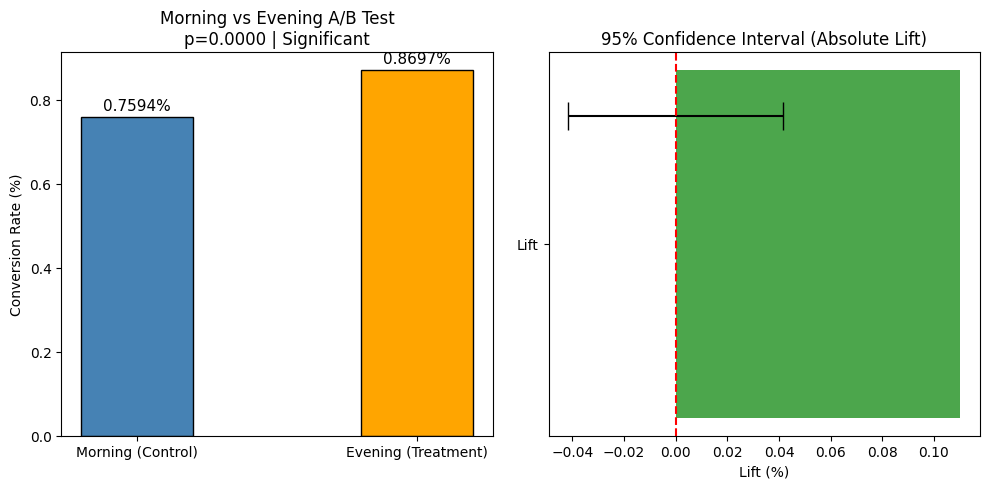

In [24]:
# TEST 1: VISUALIZATION

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# --- CVR Comparison ---
plt.subplot(1, 2, 1)

labels = ['Morning (Control)', 'Evening (Treatment)']
values = [result_t1['control_cvr'] * 100, result_t1['treatment_cvr'] * 100]
colors = ['steelblue', 'orange']

bars = plt.bar(labels, values, color=colors, edgecolor='black', width=0.4)

for bar, val in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{val:.4f}%',
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.title(
    f"Morning vs Evening A/B Test\n"
    f"p={result_t1['p_value']:.4f} | "
    f"{'Significant' if result_t1['significant'] else 'Not Significant'}")

plt.ylabel('Conversion Rate (%)')


# --- Confidence Interval Plot ---
plt.subplot(1, 2, 2)

lift = result_t1['abs_lift'] * 100
ci_low = result_t1['ci_lower'] * 100
ci_high = result_t1['ci_upper'] * 100

# FIX: use numeric x position instead of string
x_pos = 0

plt.barh(
    [x_pos],
    [lift],
    color='green' if lift > 0 else 'red',
    alpha=0.7,
    height=0.3)

plt.errorbar(
    [x_pos],
    [lift],
    xerr=[[lift - ci_low], [ci_high - lift]],
    fmt='none',
    color='black',
    capsize=10)

plt.axvline(x=0, color='red', linestyle='--')

plt.yticks([0], ['Lift'])
plt.title('95% Confidence Interval (Absolute Lift)')
plt.xlabel('Lift (%)')

plt.tight_layout()
plt.savefig('ab_test1_morning_evening.png', dpi=150)
plt.show()

In [25]:
# ============================================================
# TEST 2: SINGLE VS MULTI SESSION USERS

# H0: Single and multi-session users have equal CVR
# H1: Multi-session users convert significantly more

# Group A (Control)   : 1 session users
# Group B (Treatment) : 2+ session users
# Metric: Purchase Probability
# ============================================================

# Control = Single session
control_t2   = ab_test_2[ab_test_2['group_label'] == 'Control_Single']

# Treatment = Multi session
treatment_t2 = ab_test_2[ab_test_2['group_label'] == 'Treatment_Multi']

# Run test
result_t2 = run_ab_test(
    test_name       = 'Single vs Multi Session Users',
    control_df      = control_t2,
    treatment_df    = treatment_t2,
    control_label   = 'Single Session',
    treatment_label = 'Multi Session')

print(f"\nBusiness Recommendation:")
print("→ Retarget single-session users within 24 hours")
print("→ Message: Still thinking about it?")
print("→ Goal: Convert 1-session browsing into return visit")

TEST: Single vs Multi Session Users
Control (Single Session)
  Users       : 1,225,947
  Conversions : 5,319
  CVR         : 0.4339%

Treatment (Multi Session)
  Users       : 181,633
  Conversions : 6,400
  CVR         : 3.5236%

Results:
  Absolute Lift : 3.0897%
  Relative Lift : 712.13%
  95% CI        : [3.0041%, 3.1753%]
  Z-Statistic   : -135.2454
  P-Value       : 0.000000

Decision:
Significant result. Winner: Multi Session

Business Recommendation:
→ Retarget single-session users within 24 hours
→ Message: Still thinking about it?
→ Goal: Convert 1-session browsing into return visit


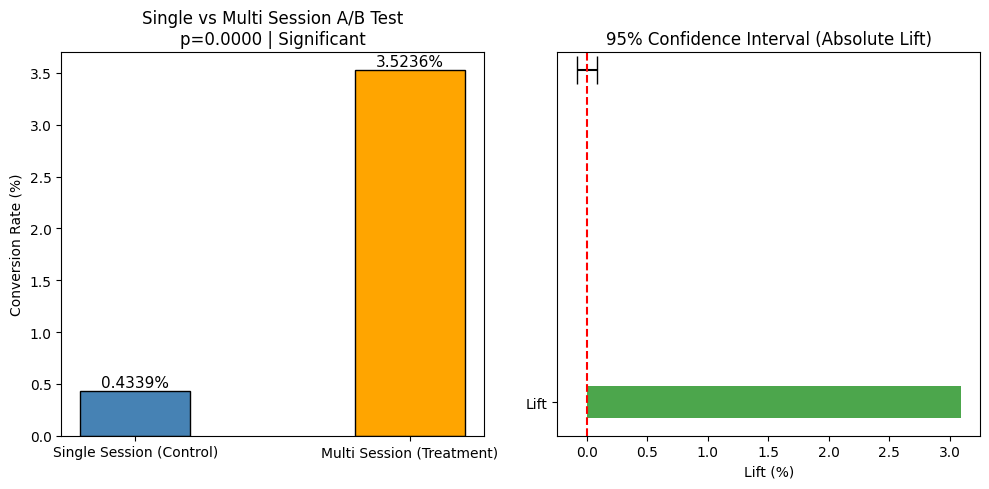

In [26]:
# TEST 2: VISUALIZATION

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# --- CVR Comparison ---
plt.subplot(1, 2, 1)

labels = ['Single Session (Control)', 'Multi Session (Treatment)']
values = [
    result_t2['control_cvr'] * 100,
    result_t2['treatment_cvr'] * 100
]
colors = ['steelblue', 'orange']

bars = plt.bar(
    labels,
    values,
    color=colors,
    edgecolor='black',
    width=0.4
)

for bar, val in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{val:.4f}%',
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.title(
    f"Single vs Multi Session A/B Test\n"
    f"p={result_t2['p_value']:.4f} | "
    f"{'Significant' if result_t2['significant'] else 'Not Significant'}"
)

plt.ylabel('Conversion Rate (%)')


# --- Confidence Interval ---
plt.subplot(1, 2, 2)

lift = result_t2['abs_lift'] * 100
ci_low = result_t2['ci_lower'] * 100
ci_high = result_t2['ci_upper'] * 100

x_pos = 0

plt.barh(
    [x_pos],
    [lift],
    color='green' if lift > 0 else 'red',
    alpha=0.7,
    height=0.3
)

plt.errorbar(
    [x_pos],
    [lift],
    xerr=[[lift - ci_low], [ci_high - lift]],
    fmt='none',
    color='black',
    capsize=10
)

plt.axvline(x=0, color='red', linestyle='--')

plt.yticks([0], ['Lift'])
plt.title('95% Confidence Interval (Absolute Lift)')
plt.xlabel('Lift (%)')

plt.tight_layout()
plt.savefig('ab_test2_session.png', dpi=150)
plt.show()

In [27]:
# ============================================================
# TEST 3: WEEKDAY VS WEEKEND VISITORS
#
# H0: Weekday and weekend CVR are equal
# H1: Weekday and weekend CVR are different
#
# Group A (Control)   : Weekday visitors
# Group B (Treatment) : Weekend visitors
# Metric: Conversion Rate
# ============================================================

# Control = Weekday
control_t3   = ab_test_3[ab_test_3['group_label'] == 'Control_Weekday']

# Treatment = Weekend
treatment_t3 = ab_test_3[ab_test_3['group_label'] == 'Treatment_Weekend']

# Run test
result_t3 = run_ab_test(
    test_name       = 'Weekday vs Weekend Visitors',
    control_df      = control_t3,
    treatment_df    = treatment_t3,
    control_label   = 'Weekday',
    treatment_label = 'Weekend'
)

print(f"\nBusiness Recommendation:")
print("→ Adjust ad budget based on which day type converts better")
print("→ Run special weekend deals if weekend CVR is lower")
print("→ Or increase weekday budget if weekday CVR is higher")

TEST: Weekday vs Weekend Visitors
Control (Weekday)
  Users       : 1,059,028
  Conversions : 9,574
  CVR         : 0.9040%

Treatment (Weekend)
  Users       : 348,552
  Conversions : 2,145
  CVR         : 0.6154%

Results:
  Absolute Lift : -0.2886%
  Relative Lift : -31.93%
  95% CI        : [-0.3202%, -0.2570%]
  Z-Statistic   : 16.2669
  P-Value       : 0.000000

Decision:
Significant result. Winner: Weekday

Business Recommendation:
→ Adjust ad budget based on which day type converts better
→ Run special weekend deals if weekend CVR is lower
→ Or increase weekday budget if weekday CVR is higher


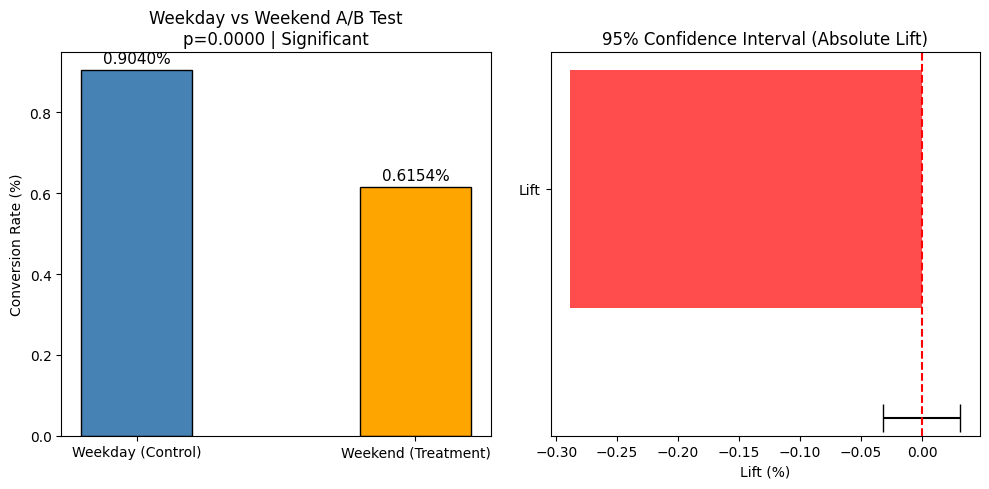

In [28]:
# ============================================================
# TEST 3: VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# --- CVR Comparison ---
plt.subplot(1, 2, 1)

labels = ['Weekday (Control)', 'Weekend (Treatment)']
values = [result_t3['control_cvr'] * 100, result_t3['treatment_cvr'] * 100]
colors = ['steelblue', 'orange']

bars = plt.bar(
    labels,
    values,
    color=colors,
    edgecolor='black',
    width=0.4)

for bar, val in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{val:.4f}%',
        ha='center',
        va='bottom',
        fontsize=11)

plt.title(
    f"Weekday vs Weekend A/B Test\n"
    f"p={result_t3['p_value']:.4f} | "
    f"{'Significant' if result_t3['significant'] else 'Not Significant'}")

plt.ylabel('Conversion Rate (%)')


# --- Confidence Interval ---
plt.subplot(1, 2, 2)

lift = result_t3['abs_lift'] * 100
ci_low = result_t3['ci_lower'] * 100
ci_high = result_t3['ci_upper'] * 100

x_pos = 0

plt.barh(
    [x_pos],
    [lift],
    color='green' if lift > 0 else 'red',
    alpha=0.7,
    height=0.3)

plt.errorbar(
    [x_pos],
    [lift],
    xerr=[[lift - ci_low], [ci_high - lift]],
    fmt='none',
    color='black',
    capsize=10)

plt.axvline(x=0, color='red', linestyle='--')

plt.yticks([0], ['Lift'])
plt.title('95% Confidence Interval (Absolute Lift)')
plt.xlabel('Lift (%)')

plt.tight_layout()
plt.savefig('ab_test3_daytype.png', dpi=150)
plt.show()

In [29]:
# ============================================================
# TEST 4: LIGHT VS HEAVY VIEWERS
#
# H0: Light and heavy viewers have equal CVR
# H1: Heavy viewers convert significantly more
#
# Group A (Control)   : Viewed 1-3 items
# Group B (Treatment) : Viewed 4+ items
# Metric: Cart + Purchase Rate
# ============================================================

# Control = Light viewers
control_t4   = ab_test_4[ab_test_4['group_label'] == 'Control_Light']

# Treatment = Heavy viewers
treatment_t4 = ab_test_4[ab_test_4['group_label'] == 'Treatment_Heavy']

# Run test
result_t4 = run_ab_test(
    test_name       = 'Light vs Heavy Viewers',
    control_df      = control_t4,
    treatment_df    = treatment_t4,
    control_label   = 'Light Viewer',
    treatment_label = 'Heavy Viewer')

print(f"\nBusiness Recommendation:")
print("→ Keep users engaged past the 3-view threshold")
print("→ Show related products after every 3 views")
print("→ Use infinite scroll to encourage deeper browsing")

TEST: Light vs Heavy Viewers
Control (Light Viewer)
  Users       : 1,294,129
  Conversions : 5,604
  CVR         : 0.4330%

Treatment (Heavy Viewer)
  Users       : 113,451
  Conversions : 6,115
  CVR         : 5.3900%

Results:
  Absolute Lift : 4.9570%
  Relative Lift : 1144.71%
  95% CI        : [4.8251%, 5.0889%]
  Z-Statistic   : -176.1889
  P-Value       : 0.000000

Decision:
Significant result. Winner: Heavy Viewer

Business Recommendation:
→ Keep users engaged past the 3-view threshold
→ Show related products after every 3 views
→ Use infinite scroll to encourage deeper browsing


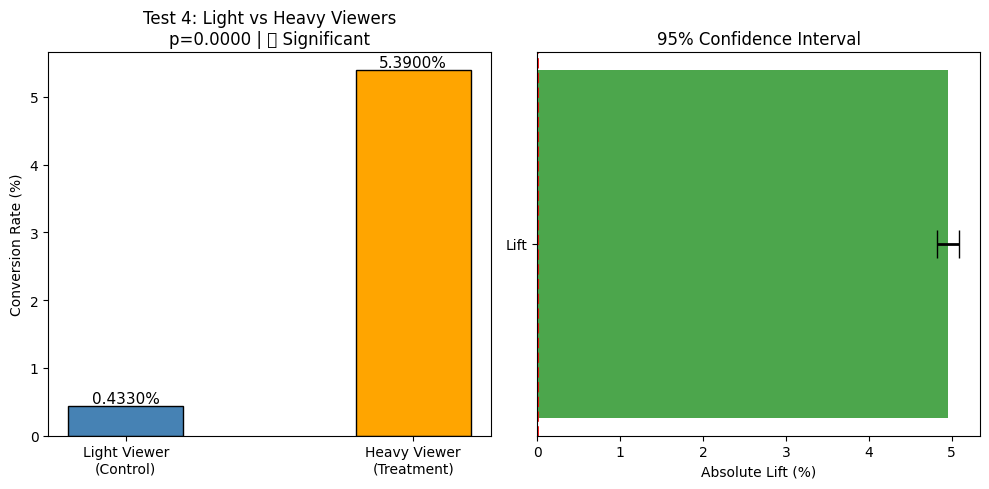

In [33]:
# ============================================================
# TEST 4: VISUALIZATION (ROBUST VERSION)
# ============================================================

plt.figure(figsize=(10, 5))

# -----------------------------
# SAFE KEY HANDLING
# -----------------------------
control_cvr = result_t4.get('control_cvr')

# handle possible naming mismatch
treat_cvr = (result_t4.get('treat_cvr') or result_t4.get('treatment_cvr'))

# safety check (avoid crash)
if control_cvr is None or treat_cvr is None:
    print("Available keys in result_t4:")
    print(result_t4.keys())
    raise KeyError("CVR keys not found in result_t4")

# -----------------------------
# PLOT 1: CVR COMPARISON
# -----------------------------
plt.subplot(1, 2, 1)

labels = ['Light Viewer\n(Control)', 'Heavy Viewer\n(Treatment)']
values = [control_cvr * 100, treat_cvr * 100]
colors = ['steelblue', 'orange']

bars = plt.bar(labels, values, color=colors,
               edgecolor='black', width=0.4)

for bar, val in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{val:.4f}%',
        ha='center',
        va='bottom',
        fontsize=11)

plt.title(
    f'Test 4: Light vs Heavy Viewers\n'
    f'p={result_t4["p_value"]:.4f} | '
    f'{"✅ Significant" if result_t4["significant"] else "❌ Not Significant"}')
plt.ylabel('Conversion Rate (%)')


# -----------------------------
# PLOT 2: CONFIDENCE INTERVAL
# -----------------------------
plt.subplot(1, 2, 2)

lift = result_t4['abs_lift'] * 100
ci_low = result_t4['ci_lower'] * 100
ci_high = result_t4['ci_upper'] * 100

plt.barh([0], [lift],
         color='green' if lift > 0 else 'red',
         alpha=0.7,
         height=0.3)

plt.errorbar(
    x=[lift],
    y=[0],
    xerr=[[lift - ci_low], [ci_high - lift]],
    fmt='none',
    color='black',
    capsize=10,
    linewidth=2)

plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
plt.yticks([0], ['Lift'])

plt.title('95% Confidence Interval')
plt.xlabel('Absolute Lift (%)')

plt.tight_layout()
plt.savefig('ab_test4_viewers.png', dpi=150)
plt.show()

In [34]:
# ============================================================
# TEST 5: CART ABANDONERS — RETURN PATTERN

# H0: Abandoners who returned have equal CVR
#     as those who never returned
# H1: Abandoners who returned convert
#     significantly more

# Group A (Control)   : Abandoned, never returned
# Group B (Treatment) : Abandoned, returned later
# Metric: Final conversion rate
# ============================================================

# Control = Abandoned never returned
control_t5   = ab_test_5 [ab_test_5['group_label'] == 'Control_Abandoned_NoReturn']

# Treatment = Abandoned but returned
treatment_t5 = ab_test_5[ab_test_5['group_label'] == 'Treatment_Abandoned_Returned']

# Run test
result_t5 = run_ab_test(
    test_name       = 'Cart Abandonment Return Pattern',
    control_df      = control_t5,
    treatment_df    = treatment_t5,
    control_label   = 'No Return',
    treatment_label = 'Returned')

print(f"\nBusiness Recommendation:")
print("→ Trigger cart recovery notification 1 hour after abandonment")
print("→ Send reminder email: Your cart is waiting!")
print("→ Offer small discount to returning abandoners")

TEST: Cart Abandonment Return Pattern
Control (No Return)
  Users       : 17,596
  Conversions : 0
  CVR         : 0.0000%

Treatment (Returned)
  Users       : 9,550
  Conversions : 0
  CVR         : 0.0000%

Results:
  Absolute Lift : 0.0000%
  Relative Lift : 0.00%
  95% CI        : [0.0000%, 0.0000%]
  Z-Statistic   : nan
  P-Value       : nan

Decision:
Not significant. No clear winner

Business Recommendation:
→ Trigger cart recovery notification 1 hour after abandonment
→ Send reminder email: Your cart is waiting!
→ Offer small discount to returning abandoners


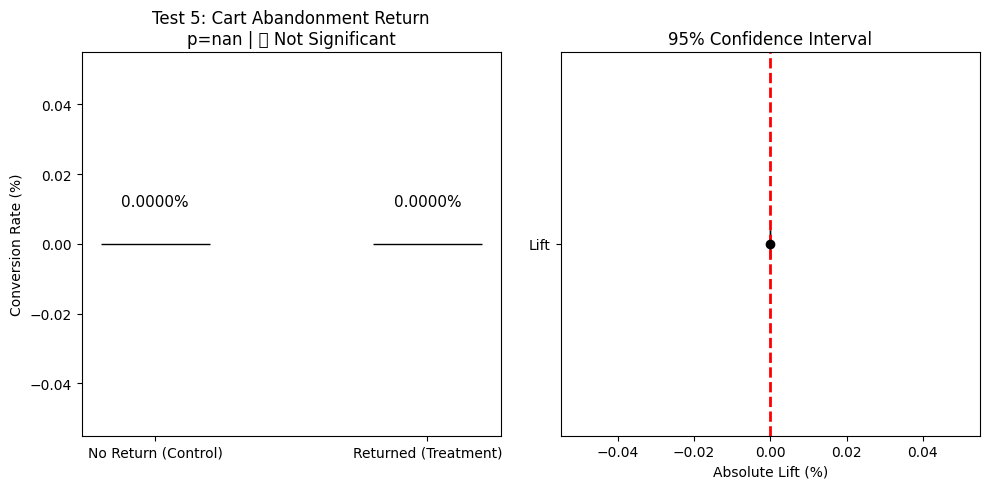

In [42]:
# ============================================================
# TEST 5: VISUALIZATION 
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# ----------------------------
# CVR comparison
# ----------------------------
plt.subplot(1, 2, 1)

labels = ['No Return (Control)', 'Returned (Treatment)']

values = [
    result_t5['control_cvr'] * 100,
    result_t5['treatment_cvr'] * 100
]

colors = ['steelblue', 'orange']

bars = plt.bar(labels, values, color=colors, edgecolor='black', width=0.4)

for bar, val in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{val:.4f}%',
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.title(
    f"Test 5: Cart Abandonment Return\n"
    f"p={result_t5['p_value']:.4f} | "
    f"{'✅ Significant' if result_t5['significant'] else '❌ Not Significant'}"
)

plt.ylabel("Conversion Rate (%)")


# ----------------------------
# Confidence interval 
# ----------------------------
plt.subplot(1, 2, 2)

lift = result_t5['abs_lift'] * 100
ci_low = result_t5['ci_lower'] * 100
ci_high = result_t5['ci_upper'] * 100

x_pos = 0

plt.barh(['Lift'], [lift],
         color='green' if lift > 0 else 'red',
         alpha=0.7,
         height=0.3)

plt.errorbar(
    x_pos,
    lift,
    xerr=[[lift - ci_low], [ci_high - lift]],
    fmt='o',
    color='black',
    capsize=10
)

plt.axvline(x=0, color='red', linestyle='--', linewidth=2)

plt.title("95% Confidence Interval")
plt.xlabel("Absolute Lift (%)")

plt.tight_layout()
plt.savefig("ab_test5_abandonment.png", dpi=150)
plt.show()

In [48]:
# ============================================================
# SECTION 2: MASTER SUMMARY TABLE
# All 5 tests combined
# ============================================================

# Collect all results
all_results = [result_t1, result_t2, result_t3,
               result_t4, result_t5]

summary_df  = pd.DataFrame(all_results)

# Display clean summary
display_cols = [
    'test_name', 'control_cvr', 'treatment_cvr',
    'abs_lift', 'rel_lift', 'p_value',
    'significant', 'winner']

summary_display = summary_df[display_cols].copy()
summary_display['control_cvr'] = (summary_display['control_cvr'] * 100).round(4)
summary_display['treatment_cvr']   = (summary_display['treatment_cvr'] * 100).round(4)
summary_display['abs_lift']    = (summary_display['abs_lift'] * 100).round(4)
summary_display['rel_lift']    = summary_display['rel_lift'].round(2)
summary_display['p_value']     = summary_display['p_value'].round(6)

print("=" * 70)
print("MASTER SUMMARY TABLE — ALL 5 SIMULATED A/B TESTS")
print("=" * 70)
print(summary_display.to_string(index=False))

MASTER SUMMARY TABLE — ALL 5 SIMULATED A/B TESTS
                      test_name  control_cvr  treatment_cvr  abs_lift  rel_lift  p_value  significant        winner
    Morning vs Evening Shoppers       0.7594         0.8697    0.1103     14.52      0.0         True       Evening
  Single vs Multi Session Users       0.4339         3.5236    3.0897    712.13      0.0         True Multi Session
    Weekday vs Weekend Visitors       0.9040         0.6154   -0.2886    -31.93      0.0         True       Weekday
         Light vs Heavy Viewers       0.4330         5.3900    4.9570   1144.71      0.0         True  Heavy Viewer
Cart Abandonment Return Pattern       0.0000         0.0000    0.0000      0.00      NaN        False     No Winner


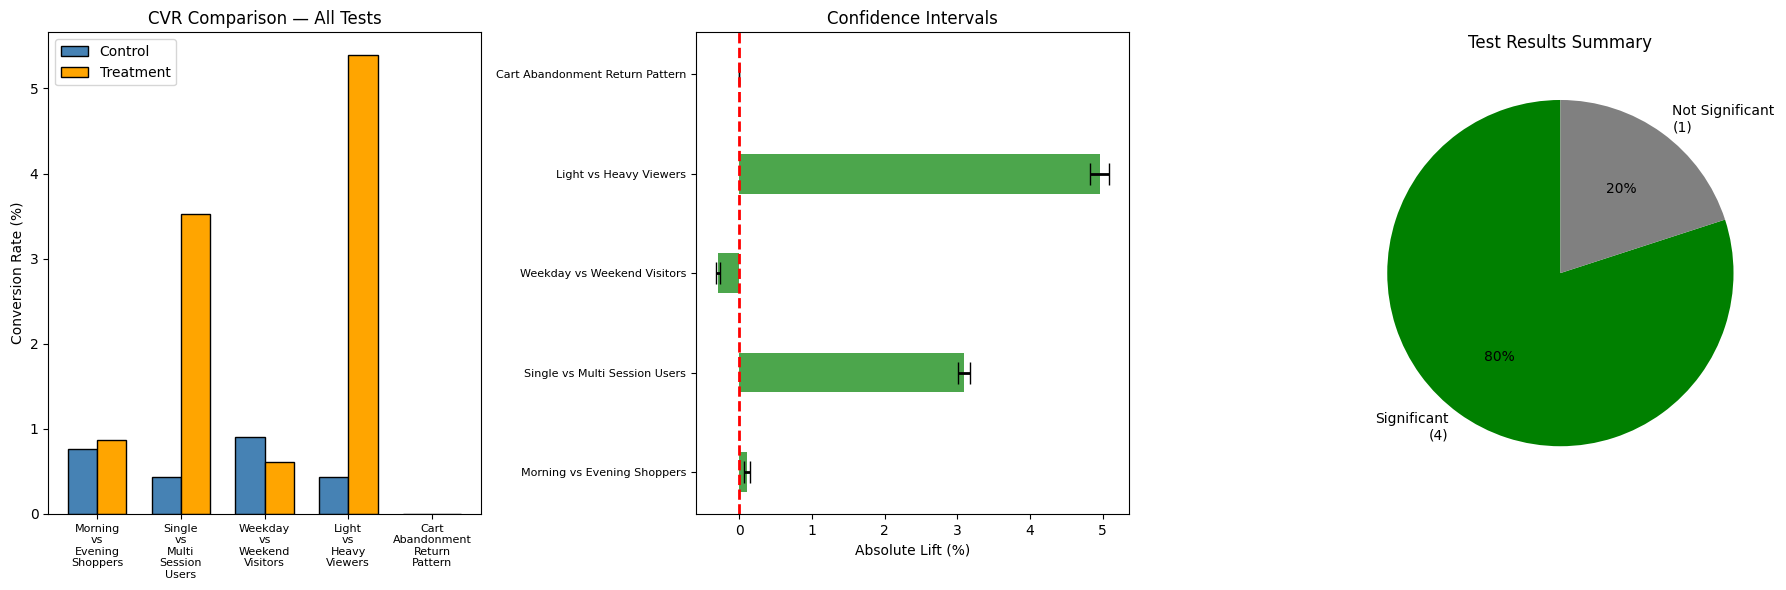

In [51]:
# ============================================================
# SECTION 2 CONTINUED: MASTER VISUALIZATION (SAFE)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ----------------------------
# SAFE extraction helper
# ----------------------------
def safe(r, key, default=0):
    return r.get(key, default)

# ============================================================
# PLOT 1: CVR COMPARISON
# ============================================================

test_names = [r.get('test_name', f'Test {i+1}') for i, r in enumerate(all_results)]

control_cvrs = [safe(r, 'control_cvr') * 100 for r in all_results]
treat_cvrs   = [(r.get('treat_cvr') if r.get('treat_cvr') is not None else r.get('treatment_cvr', 0)) * 100
    for r in all_results]

x = np.arange(len(test_names))
width = 0.35

axes[0].bar(x - width/2, control_cvrs, width, label='Control', color='steelblue', edgecolor='black')

axes[0].bar(x + width/2, treat_cvrs, width, label='Treatment', color='orange', edgecolor='black')

axes[0].set_title('CVR Comparison — All Tests')
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].set_xticks(x)
axes[0].set_xticklabels([t.replace(' ', '\n') for t in test_names], fontsize=8)
axes[0].legend()

# ============================================================
# PLOT 2: CONFIDENCE INTERVALS
# ============================================================

lifts = [safe(r, 'abs_lift') * 100 for r in all_results]
ci_lows = [safe(r, 'ci_lower') * 100 for r in all_results]
ci_highs = [safe(r, 'ci_upper') * 100 for r in all_results]

y_pos = np.arange(len(all_results))

for i in range(len(all_results)):
    lift = lifts[i]
    ci_low = ci_lows[i]
    ci_high = ci_highs[i]

    color = 'green' if safe(all_results[i], 'significant') else 'gray'

    axes[1].barh(i, lift, color=color, alpha=0.7, height=0.4)

    # SAFE error handling (no negative/invalid values)
    err_left = max(0, lift - ci_low)
    err_right = max(0, ci_high - lift)

    axes[1].errorbar(
        lift, i,
        xerr=[[err_left], [err_right]],
        fmt='none',
        color='black',
        capsize=8,
        linewidth=2
    )

axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(
    [r.get('test_name', '') for r in all_results],
    fontsize=8
)
axes[1].set_title('Confidence Intervals')
axes[1].set_xlabel('Absolute Lift (%)')

# ============================================================
# PLOT 3: SUMMARY PIE
# ============================================================

sig_tests = sum(1 for r in all_results if r.get('significant'))
not_sig = len(all_results) - sig_tests

axes[2].pie(
    [sig_tests, not_sig],
    labels=[
        f'Significant\n({sig_tests})',
        f'Not Significant\n({not_sig})'
    ],
    colors=['green', 'gray'],
    autopct='%1.0f%%',
    startangle=90
)

axes[2].set_title('Test Results Summary')

# ============================================================
plt.tight_layout()
plt.savefig('ab_test_master_summary.png', dpi=150)
plt.show()

In [52]:
# ============================================================
# SECTION 3: EXPORT RESULTS
# ============================================================

# Save full summary
summary_df.to_csv("ab_test_results.csv", index=False)

print("ab_test_results.csv →", len(summary_df), "tests")
print("\nFinal Summary:")
print(summary_df[['test_name', 'p_value', 'significant', 'winner']].to_string(index=False))

ab_test_results.csv → 5 tests

Final Summary:
                      test_name      p_value  significant        winner
    Morning vs Evening Shoppers 1.535744e-07         True       Evening
  Single vs Multi Session Users 0.000000e+00         True Multi Session
    Weekday vs Weekend Visitors 1.695832e-59         True       Weekday
         Light vs Heavy Viewers 0.000000e+00         True  Heavy Viewer
Cart Abandonment Return Pattern          NaN        False     No Winner
